# Quick Reference: Autograd Basics in PyTorch

| Name                                        | Type                     | Returns                         | Typical Use                                                                                                                        |
| ------------------------------------------- | ------------------------ | ------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| `torch.randn(size=..., requires_grad=True)` | Tensor constructor       | Tensor with random values       | Creates a tensor sampled from a standard normal distribution. Setting `requires_grad=True` enables gradient tracking for autograd. |
| `y.backward()`                              | Tensor method            | `None` (but computes gradients) | Runs backpropagation from scalar `y`, computing gradients for all leaf tensors that contributed to it.                             |
| `x.grad`                                    | Tensor attribute         | Tensor (same shape as `x`)      | Stores the gradient of the loss (or output) with respect to `x` after `.backward()` is called.                                     |
| `grad.zero_()`                              | Tensor method (in-place) | `None`                          | Clears gradients in-place, usually called before the next optimization step to prevent gradient accumulation.                      |


*   Recall from Section 2.4 that calculating derivatives is the crucial step in all the optimization algorithms that we will use to train deep networks.
> *   While the calculations are straightforward, working them out by hand can be tedious and error-prone, and these issues only grow as our models become more complex.
> *   Fortunately all modern deep learning frameworks take this work off our plates by offering automatic differentiation (often shortened to autograd).
> *  As we pass data through each successive function, the framework builds a computational graph that tracks how each value depends on others.
> *  To calculate derivatives, automatic differentiation works backwards through this graph applying the chain rule.
> *  The computational algorithm for applying the chain rule in this fashion is called backpropagation.

*  While autograd libraries have become a hot concern over the past decade, they have a long history.
> *  In fact the earliest references to autograd date back over half of a century (Wengert, 1964).
> *  The core ideas behind modern backpropagation date to a PhD thesis from 1980 (Speelpenning, 1980) and were further developed in the late 1980s (Griewank, 1989).
> *  While backpropagation has become the default method for computing gradients, it is not the only option.
> *  For instance, the Julia programming language employs forward propagation (Revels et al., 2016).
> *  Before exploring methods, let’s first master the autograd package.
     

In [ ]:
import torch

# 2.5.1. A Simple Function

*   Let's assume that we are interested
in (**differentiating the function
$y = 2\mathbf{x}^{\top}\mathbf{x}$
with respect to the column vector $\mathbf{x}$.**)
*   To start, we assign `x` an initial value.

In [ ]:
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

*   [**Before we calculate the gradient
of $y$ with respect to $\mathbf{x}$,
we need a place to store it.**]
*   In general, we avoid allocating new memory
every time we take a derivative
because deep learning requires
successively computing derivatives
with respect to the same parameters
a great many times,
and we might risk running out of memory.
*   Note that the gradient of a scalar-valued function
with respect to a vector $\mathbf{x}$
is vector-valued with
the same shape as $\mathbf{x}$.







In [ ]:
# Can also create x = torch.arange(4.0, requires_grad=True)
x.requires_grad_(True)
x.grad  # The default value is None

*   (**We now calculate our function of `x` and assign the result to `y`.**)




In [ ]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

`y = 2 * torch.dot(x, x)` means 2 times the squared length of vector x:

$$
y = 2(x \cdot x)
$$

`torch.dot(x, x)` = dot product of `x` with itself:

$$
x \cdot x = x_1^2+x_2^2+x_3^2
$$

So:

$$
y = 2(x_1^2+x_2^2+x_3^2)
$$

Becomes:
$$
y = 2(1^2+2^2+3^2)
$$

$$
= 2(14)
$$

$$
= 28
$$

where `x = [0, 1, 2, 3]` where each x represents the component of vector `x`.

*   [**We can now take the gradient of `y`
with respect to `x`**] by calling
its `backward` method.
> *   `backward()` calculates the gradient of the output with respect to each input that requires gradients.
*   Next, we can access the gradient
via `x`'s `grad` attribute.

In [ ]:
y.backward()
  #start from y and work backward through the graph to find derivatives
  #can only be called once because autograd deletes saved graph for backward calculation after the result completion
  #the result will be stored in x.grad since x was created under requires_grad_=True
  #if you don't calculate y.backward(), then x.grad will just be None (empty) since it's not computed
x.grad

tensor([ 0.,  4.,  8., 12.])

### 1. Expand the function

`torch.dot(x, x)` is the dot product of `x` with itself:

$$
x \cdot x = x_0^2+x_1^2+x_2^2+x_3^2
$$

So:

$$
y = 2(x_0^2+x_1^2+x_2^2+x_3^2)
$$


### 2. What `backward()` does

`y.backward()` calculates:

$$
\frac{\partial y}{\partial x_i}
$$

Meaning:

> How much does `y` change if one element of `x` changes?

For one element:

$$
\frac{\partial}{\partial x_0}(2x_0^2)
$$

The derivative of:

$$
x_0^2
$$

is:

$$
2x_0
$$

So:

$$
2 \times 2x_0 = 4x_0
$$

The same applies to every element:

$$
\frac{\partial y}{\partial x_i}=4x_i
$$


### 3. Plug in the values of x

Given:

$$
x=[0,1,2,3]
$$

The gradients are:

$$
[4(0),4(1),4(2),4(3)]
$$

which gives:

$$
[0,4,8,12]
$$

PyTorch stores this automatically in:

```python
x.grad

*   (**We already know that the gradient of the function $y = 2\mathbf{x}^{\top}\mathbf{x}$
with respect to $\mathbf{x}$ should be $4\mathbf{x}$.**)
*   We can now verify that the automatic gradient computation
and the expected result are identical.






In [ ]:
x.grad == 4 * x

tensor([True, True, True, True])

*   [**Now let's calculate
another function of `x`
and take its gradient.**]
> *   Note that PyTorch does not automatically reset the gradient buffer when we record a new gradient.
> *   Instead, the new gradient is added to the already-stored gradient.
> *   This behavior comes in handy when we want to optimize the sum of multiple objective functions.
> *   To reset the gradient buffer, we can call `x.grad.zero_()` as follows:


*   For `y = x.sum()`, the gradient is all 1s because each element of `x` contributes directly to `y` with a 1-to-1 relationship.
> *   The derivative asks: “if I increase this element by a small amount, how much does `y` change?”
> *   Since $y = x₀ + x₁ + x₂ + x₃$, increasing $x₀$ by 1 increases `y` by 1 increasing $x₁$ by 1 increases `y` by 1, etc.







In [ ]:
x.grad.zero_() #reset the gradient
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

# 2.5.2. Backward for Non-Scalar Variables

*   When `y` is a vector,
the most natural representation
of the derivative of  `y`
with respect to a vector `x`
is a matrix called the *Jacobian*
that contains the partial derivatives
of each component of `y`
with respect to each component of `x`.
*   Likewise, for higher-order `y` and `x`,
the result of differentiation could be an even higher-order tensor.

*   While Jacobians do show up in some
advanced machine learning techniques,
more commonly we want to sum up
the gradients of each component of `y`
with respect to the full vector `x`,
yielding a vector of the same shape as `x`.
*   For example, we often have a vector
representing the value of our loss function
calculated separately for each example among
a *batch* of training examples.
*   Here, we just want to (**sum up the gradients
computed individually for each example**).




*   Because deep learning frameworks vary
in how they interpret gradients of
non-scalar tensors,
PyTorch takes some steps to avoid confusion.
> *   Invoking `backward` on a non-scalar elicits an error unless we tell PyTorch how to reduce the object to a scalar.
> *   More formally, we need to provide some vector $\mathbf{v}$ such that `backward` will compute $\mathbf{v}^\top \partial_{\mathbf{x}} \mathbf{y}$ rather than $\partial_{\mathbf{x}} \mathbf{y}$.
> *   This next part may be confusing, but for reasons that will become clear later, this argument (representing $\mathbf{v}$) is named `gradient`.
*   For a more detailed description, see Yang Zhang's
[Medium post](https://zhang-yang.medium.com/the-gradient-argument-in-pytorchs-backward-function-explained-by-examples-68f266950c29).






In [ ]:
x.grad.zero_() #clears existing x.grad
y = x * x # x*x = x^2 and the gradient is 2x
y.backward(gradient=torch.ones(len(y))) #faster: y.sum().backward(), take a weighted sum of the outputs of y, using weights [1, 1, 1], and differentiate that
x.grad

tensor([0., 2., 4., 6.])

# 2.5.3. Detaching Computation

*   Sometimes, we wish to [**move some calculations
outside of the recorded computational graph.**]
> *   For example, say that we use the input to create some auxiliary intermediate terms for which we do not want to compute a gradient.
> *   In this case, we need to *detach* the respective computational graph from the final result.

*   The following toy example makes this clearer: suppose we have `z = x * y` and `y = x * x` but we want to focus on the *direct* influence of `x` on `z` rather than the influence conveyed via `y`.
> *   In this case, we can create a new variable `u`that takes the same value as `y` but whose *provenance* (how it was created) has been wiped out.
> *   Thus `u` has no ancestors in the graph and gradients do not flow through `u` to `x`.
> *   For example, taking the gradient of `z = x * u` will yield the result `u`,
(not `3 * x * x` as you might have expected since `z = x * x * x`).






In [ ]:
x.grad.zero_()
y = x * x
u = y.detach() #u has the same values as y, but autograd treats u as a constant via detach()
z = u *x

z.sum().backward() #the gradient of x for z is u xinsce z = x * u
x.grad == u

tensor([True, True, True, True])

*   Note that while this procedure
detaches `y`'s ancestors
from the graph leading to `z`,
the computational graph leading to `y`
persists and thus we can calculate
the gradient of `y` with respect to `x`.

In [ ]:
x.grad.zero_()
y.sum().backward() #the graph for y = x * x stayed with pytorch, so even if you called u = y.detach() you can still calculate x.grad via y's gradient of 2x
x.grad == 2 * x

tensor([True, True, True, True])

# 2.5.4. Gradients and Python Control Flow

*   So far we reviewed cases where the path from input to output
was well defined via a function such as `z = x * x * x`.
*   Programming offers us a lot more freedom in how we compute results.
*   For instance, we can make them depend on auxiliary variables
or condition choices on intermediate results.
*   One benefit of using automatic differentiation
is that [**even if**] building the computational graph of
(**a function required passing through a maze of Python control flow**)
(e.g., conditionals, loops, and arbitrary function calls),
(**we can still calculate the gradient of the resulting variable.**)
*   To illustrate this, consider the following code snippet where
the number of iterations of the `while` loop
and the evaluation of the `if` statement
both depend on the value of the input `a`.






In [ ]:
def f(a):
  '''
    Start with b = 2a. Keep doubling b until its L2 (Euclidean) norm is >1000.
    If the sum of all elements in b is positive, return b;
    otherwise return 100 * b.
  '''

  b = a * 2
  while b.norm() < 1000: #keep doubling b until its L2 (Euclidean) norm is at least 1000.
    b = b * 2
  if b.sum() > 0: #check if the sum of all elements in b is positive (e.g. [-1, 1] would not pass), if b is empty an AttrributeError would return
    c = b
  else:
    c = 100 * b
  return c

*   Below, we call this function, passing in a random value, as input.
*   Since the input is a random variable,
we do not know what form
the computational graph will take.
*   However, whenever we execute `f(a)`
on a specific input, we realize
a specific computational graph
and can subsequently run `backward`.






In [ ]:
a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

*   Even though our function `f` is, for demonstration purposes, a bit contrived, its dependence on the input is quite simple:
> *   it is a *linear* function of `a` with piecewise defined scale.
> *   As such, `f(a) / a` is a vector of constant entries and, moreover, `f(a) / a` needs to match the gradient of `f(a)` with respect to `a`.







In [ ]:
a.grad == d/a

tensor(True)

## Key idea

Once execution is finished (where $k$ is a constant determined by the execution path (loop iterations and branch choice), and is independent of $a$ for that fixed computation graph):

$$
d = k a
$$

## 1. Differentiate both sides

$$
\frac{dd}{da} = k
$$

---

## 2. Express \(k\) using \(d\)

Since:

$$
d = k a
$$

divide both sides by \(a\) (assuming \(a \neq 0\)):

$$
\frac{d}{a} = \frac{k a}{a} = k
$$

---

## 3. Final result

$$
\frac{dd}{da} = \frac{d}{a}
$$

So PyTorch gives:

```python
a.grad == d / a

*   Dynamic control flow is very common in deep learning.
*   For instance, when processing text, the computational graph
depends on the length of the input.
*   In these cases, automatic differentiation
becomes vital for statistical modeling
since it is impossible to compute the gradient *a priori*.






# 2.5.5. Discussion

*   You have now gotten a taste of the power of automatic differentiation.
*   The development of libraries for calculating derivatives
both automatically and efficiently
has been a massive productivity booster
for deep learning practitioners,
liberating them so they can focus on less menial.
*   Moreover, autograd lets us design massive models for which pen and paper gradient computations would be prohibitively time consuming.
*   Interestingly, while we use autograd to *optimize* models (in a statistical sense) the *optimization* of autograd libraries themselves (in a computational sense) is a rich subject of vital interest to framework designers.
*   Here, tools from compilers and graph manipulation are leveraged to compute results in the most expedient and memory-efficient manner.
*   For now, try to remember these basics:
> *   (i) attach gradients to those variables with respect to which we desire derivatives;
> *   (ii) record the computation of the target value;
> *   (iii) execute the backpropagation function; and
> *   (iv) access the resulting gradient.

# 2.5.6. Exercises

1. Why is the second derivative much more expensive to compute than the first derivative?



*   Second derivatives are expensive because you must differentiate through the entire first derivative computation, which requires building and traversing an additional computation graph with higher memory and compute cost.
*   The second derivative is more expensive because you must store and differentiate [**not just the original operations, but also how each operation produced its first derivative**], which introduces extra graph structure, extra intermediate values, and often dense second-order interactions.

## Why second derivatives are more expensive than first derivatives

---

## 1. First derivative already builds a full graph

When you compute:

$$
y = f(x)
$$

PyTorch builds a computation graph like:

$$
x \rightarrow op_1 \rightarrow op_2 \rightarrow op_3 \rightarrow y
$$

During `backward()`, PyTorch traverses this graph in reverse and computes:

$$
\frac{dy}{dx}
$$

### Key point

- Only **local derivatives** are needed
- Each node stores just enough information to compute its gradient

So memory usage consists of:
- stored forward activations (sometimes freed later)
- a single backward traversal of the graph

---

## 2. Second derivative = differentiating the backward pass

Now we want:

$$
\frac{d^2 y}{dx^2}
$$

This means:

> We are differentiating the process that computed the first derivative

But the first derivative depends on:
- intermediate activations (values of $x$, hidden states, etc.)
- local Jacobians at each node

So each node is no longer just a forward/backward pair:

### First-order case

$$
\text{forward: } y = f(x)
$$

$$
\text{backward: } \frac{dy}{dx} = f'(x)
$$

### Second-order case

$$
\text{second backward: } \frac{d^2 y}{dx^2} = \frac{d}{dx}\left(f'(x)\right)
$$

---

## Why this is more expensive

### 1. More memory is required

To compute second derivatives, PyTorch must often retain:
- forward activations
- intermediate values used in the backward pass
- sometimes gradient-related intermediates

So fewer tensors can be safely discarded after the first backward pass.

---

### 2. More computation per node

Each operation must now support:
- forward computation
- first derivative computation
- derivative of the derivative

This increases per-node cost significantly.

---

### 3. The backward pass becomes differentiable

Normally:
- backward is just a sequence of fixed computations

For second derivatives:
- backward itself must be tracked as a computation graph

So you effectively get:

$$
\text{forward graph} \rightarrow \text{backward graph} \rightarrow \text{second backward graph}
$$

---

## Intuition summary

- First derivative: measures slope
- Second derivative: measures how slope changes
- Computing slope change requires tracking how the slope itself was computed

---

## Final takeaway

Second derivatives are more expensive because:

- you must retain more intermediate values
- you must differentiate through the backward computation itself
- each operation becomes part of a second computation graph
- overall compute and memory scale significantly compared to first-order autodiff


2. After running the function for backpropagation, immediately run it again and see what happens. Investigate.

*   You will get a `RuntimeError` since PyTorch deletes the computation graph immediately after `backward()` finishes unless you explicitly ask it not to.
*   To retain the computational graph, use the `retain_graph=True` argument inside `backward()`.





3. In the control flow example where we calculate the derivative of `d` with respect to `a`, what would happen if we changed the variable `a` to a random vector or a matrix?

   At this point, the result of the calculation `f(a)` is no longer a scalar. What happens to the result? How do we analyze this?

* For a tensor like $a \in \mathbb{R}^{3 \times 2 \times 2}$, PyTorch conceptually flattens it into a 12-dimensional vector when computing derivatives, so the true mathematical derivative (the Jacobian) of a scalar output would live in a $1 \times 12$ space.
* However, instead of explicitly forming this Jacobian, PyTorch computes vector–Jacobian products during backpropagation and then reshapes the result back to the original tensor shape, meaning `a.grad` has the same shape as `a` and contains the partial derivative of the output with respect to each individual element of `a`.

4. Let $f(x) = \sin(x)$. Plot the graph of $f$ and of its derivative $f'$. Do not exploit the fact that $f'(x) = \cos(x)$ but rather use automatic differentiation to get the result.

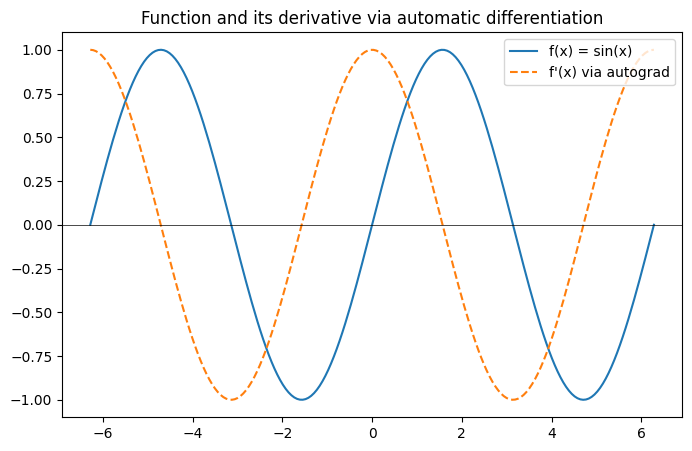

In [ ]:
import matplotlib.pyplot as plt

x = torch.linspace(-2 * torch.pi, 2 * torch.pi, 200, requires_grad=True)

y = torch.sin(x)

y.backward(torch.ones_like(x))

f_prime = x.grad

x_np = x.detach().numpy()
y_np = y.detach().numpy()
f_prime_np = f_prime.detach().numpy()

plt.figure(figsize=(8, 5))
plt.plot(x_np, y_np, label="f(x) = sin(x)")
plt.plot(x_np, f_prime_np, label="f'(x) via autograd", linestyle="--")

plt.axhline(0, color="black", linewidth=0.5)
plt.legend()
plt.title("Function and its derivative via automatic differentiation")
plt.show()

5. Let $f(x) = ((\log x^2) \cdot \sin x) + x^{-1}$. Write out a dependency graph tracing results from $x$ to $f(x)$.

In [ ]:
# single input
x = torch.tensor(2.0, requires_grad=True)

# forward pass (all in one go)
a = x**2
b = torch.log(a)
c = torch.sin(x)
d = b * c
e = x**(-1)
f = d + e

# backward pass
f.backward()

# output results
print("f(x) =", f.item())
print("df/dx =", x.grad)

# dependency graph (autograd structure)
print("\n--- Grad functions ---")
print("f:", f.grad_fn)
print("d:", d.grad_fn)
print("b:", b.grad_fn)
print("c:", c.grad_fn)
print("a:", a.grad_fn)

f(x) = 1.7605538368225098
df/dx = tensor(0.0824)

--- Grad functions ---
f: <AddBackward0 object at 0x7ee8e89e7460>
d: <MulBackward0 object at 0x7ee8e89e7460>
b: <LogBackward0 object at 0x7ee8e89e7460>
c: <SinBackward0 object at 0x7ee8e89e7460>
a: <PowBackward0 object at 0x7ee8e89e7460>
Computation graph:



6. Use the chain rule to compute the derivative $\frac{df}{dx}$ of the aforementioned function, placing each term on the dependency graph that you constructed previously.

We’ll use your function:

$$
f(x) = (\log(x^2)\cdot \sin x) + x^{-1}
$$

---

## 1. Dependency graph (recall)

We define intermediate variables:

$$
a = x^2
$$

$$
b = \log(a)
$$

$$
c = \sin x
$$

$$
d = b \cdot c
$$

$$
e = x^{-1}
$$

$$
f = d + e
$$

---

# 2. Apply chain rule step-by-step

We now compute gradients on the graph from output → input.

---

## Step 1: output node

$$
f = d + e
$$

$$
\frac{df}{dd} = 1, \quad \frac{df}{de} = 1
$$

So gradient flows equally into both branches.

---

## Step 2: product node

$$
d = b \cdot c
$$

Chain rule:

$$
\frac{df}{db} = \frac{df}{dd} \cdot \frac{dd}{db} = 1 \cdot c = c
$$

$$
\frac{df}{dc} = 1 \cdot b = b
$$

So:
- gradient to \(b\) = \(c\)
- gradient to \(c\) = \(b\)

---

## Step 3: log branch

$$
b = \log(a)
$$

$$
\frac{db}{da} = \frac{1}{a}
$$

So:

$$
\frac{df}{da} = \frac{df}{db} \cdot \frac{db}{da}
= c \cdot \frac{1}{a}
$$

$$
\frac{df}{da} = \frac{c}{a}
$$

---

## Step 4: square node

$$
a = x^2
$$

$$
\frac{da}{dx} = 2x
$$

So:

$$
\frac{df}{dx}\Big|_{\text{path 1}} = \frac{c}{a} \cdot 2x
$$

---

## Step 5: sine branch

$$
c = \sin x
$$

$$
\frac{dc}{dx} = \cos x
$$

So:

$$
\frac{df}{dx}\Big|_{\text{path 2}} = b \cdot \cos x
$$

---

## Step 6: reciprocal branch

$$
e = x^{-1}
$$

$$
\frac{de}{dx} = -x^{-2}
$$

So:

$$
\frac{df}{dx}\Big|_{\text{path 3}} = -x^{-2}
$$

---

# 3. Final combined result

$$
\frac{df}{dx}
=
\left(\frac{c}{a}\cdot 2x\right)
+
\left(b \cdot \cos x\right)
-
x^{-2}
$$

---

# 4. Substitute back original variables

Recall:

$$
a = x^2,\quad b = \log(x^2),\quad c = \sin x
$$

---

# Final answer

$$
\boxed{
\frac{df}{dx}
=
\frac{2x \sin x}{x^2}
+
\log(x^2)\cos x
-
x^{-2}
}
$$

---

# 5. Key intuition

Each path in the graph contributes one term: Total derivative = sum of all paths from \(x\) to \(f\)

7. Given the graph and the intermediate derivative results, you have a number of options when computing the gradient.

   Evaluate the result once starting from $x$ to $f$ and once from $f$ tracing back to $x$.
    
   The path from $x$ to $f$ is commonly known as *forward differentiation*, whereas the path from $f$ to $x$ is known as backward differentiation.

*   Forward differentiation propagates derivatives from input to output, while backward differentiation (backpropagation) propagates gradients from output back to input; modern deep learning frameworks primarily use backward mode because it is far more efficient for scalar loss functions.



## Forward vs Backward Differentiation — When to Use Each

---

## 1. Forward-mode differentiation (JVP)

You use forward mode when:

### ✔ Input dimension is small  
and/or  
### ✔ Output dimension is large  

---

### Why?

Forward mode propagates a **directional derivative forward through the computation**, so its cost scales with the number of inputs.

So it is efficient when:

- few inputs  
- many outputs  

---

### Typical use cases

- Sensitivity analysis  
- Physics simulations (few parameters → large system output)  
- Real-time systems where you perturb inputs slightly  
- Computing Jacobian-vector products efficiently  

---

### Key property

- Computes derivatives **along with the forward pass**  
- Requires storing less backward bookkeeping  
- More naturally parallel across outputs  

---

## 2. Backward-mode differentiation (VJP / backprop)

You use backward mode when:

### ✔ Output dimension is small (usually 1 scalar loss)  
and  
### ✔ Input dimension is large (millions of parameters)  

---

### Why?

Backward mode reuses intermediate activations and propagates gradients from output backward efficiently.

So it is efficient when:

- many parameters  
- one loss value  

---

### Typical use cases (deep learning)

- Training neural networks  
- Computing gradients of loss w.r.t. millions of weights  
- Backpropagation in PyTorch / TensorFlow / JAX  

---

### Key property

- Requires storing the computation graph (intermediate activations)  
- Very memory-intensive compared to forward mode  
- Extremely efficient for scalar loss functions  